In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn import model_selection
from sklearn import metrics
from sklearn import *
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, roc_auc_score, f1_score, make_scorer, silhouette_score, calinski_harabasz_score, davies_bouldin_score, rand_score, adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, completeness_score, v_measure_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

In [2]:
A = np.matrix([[1,2,3,4],
               [5,5,6,7],
               [1,4,2,3],
               [5,3,2,1],
               [8,1,2,2]])

df = pd.DataFrame(A,columns  = ['x1','x2','x3','x4'])
df_std  = (df - df.mean()) / (df.std())

In [3]:
cov_mat = np.cov(df_std.T)
cov_mat

array([[ 1.        , -0.31622777,  0.04811252, -0.18098843],
       [-0.31622777,  1.        ,  0.63900965,  0.61812254],
       [ 0.04811252,  0.63900965,  1.        ,  0.94044349],
       [-0.18098843,  0.61812254,  0.94044349,  1.        ]])

In [4]:
eigen_val, eigen_vectors = np.linalg.eig(cov_mat)

In [9]:
#импортируем нужный алгоритм

from sklearn.decomposition import PCA, TruncatedSVD
#определяем метод главных компонент с двумя компонентами
pca = PCA(n_components=2)
#обучаем алгоритм на наших данных
principalComponents = pca.fit_transform(df_std)

In [6]:
np.cov(np.array([3,4,1]),np.array([1,6,2])).sum()

np.float64(14.333333333333334)

In [8]:
A = np.matrix([[8,7,2,9],
               [1,3,6,3],
               [7,2,0,3],
               [10,3,1,1],
               [8,1,3,4]])
 
df = pd.DataFrame(A)
df_std  = (df - df.mean()) / (df.std())
pca = PCA(n_components=0.9)
principalComponents = pca.fit_transform(df_std)
principalComponents

array([[ 1.61145254,  1.76368007, -0.01320928],
       [-2.08441051,  1.01724955,  0.24417084],
       [ 0.29568142, -0.95946326,  0.05272576],
       [ 0.50390826, -1.24373821,  0.50808763],
       [-0.3266317 , -0.57772816, -0.79177495]])

In [ ]:
# создаём объект класса TruncatedSVD
# n_components — размерность нового пространства, n_iter — количество итераций
svd = TruncatedSVD(n_components=5, n_iter=7, random_state=42)
# обучаем модель на данных X
svd.fit(X)
# применяем уменьшение размерности к матрице X
transformed = svd.transform(X)

In [ ]:
# импортируем класс TSNE из модуля manifold библиотеки sklearn
from sklearn.manifold import TSNE
# создаём объект класса TSNE
# n_components — размерность нового пространства
tsne = TSNE(n_components=2, perplexity=30, n_iter=500, random_state=42)
# обучаем модель на данных X и применяем к матрице X уменьшение размерности
tsne.fit_transform(X)

In [14]:
country_data = pd.read_csv('C:\IDE\Math trees\Module 4\data\Country-data.csv')

<>:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
C:\Users\troyd\AppData\Local\Temp\ipykernel_20820\2198725397.py:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  country_data = pd.read_csv('C:\IDE\Math trees\Module 4\data\Country-data.csv')


In [15]:
country_data['life_expec'].max()

np.float64(82.8)

In [16]:
X = country_data.drop('country',axis =1)  
y = country_data['country']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0][0]

np.float64(1.2915323778422956)

<Axes: >

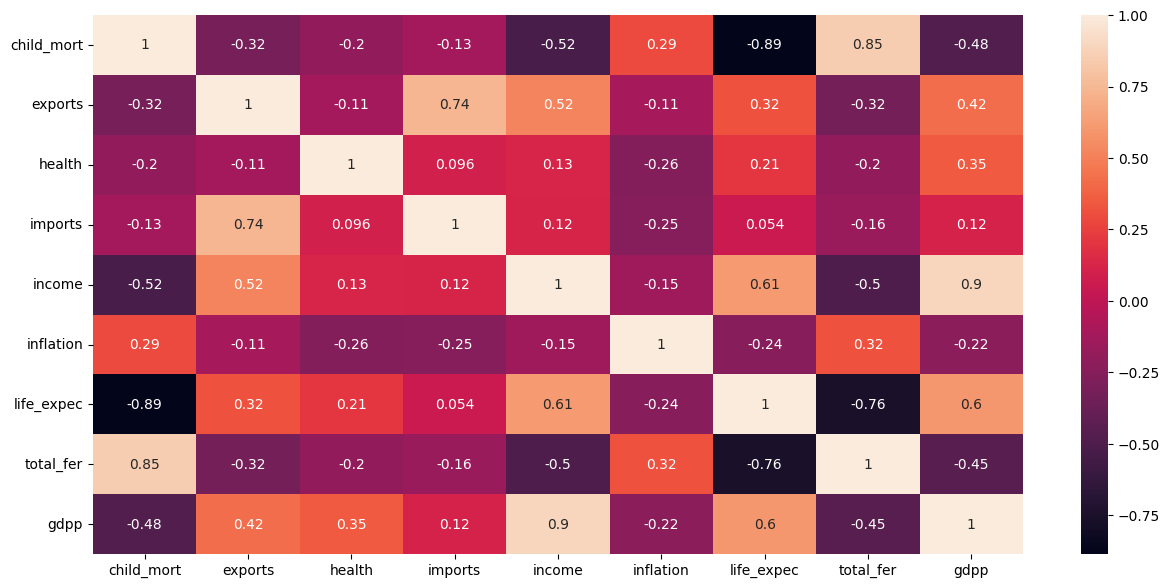

In [18]:
X_scaled_df = pd.DataFrame(X_scaled,columns=X.columns)
plt.figure(figsize = (15,7))       
sns.heatmap(X_scaled_df.corr(),annot = True)

In [19]:
pca = PCA(n_components=0.9, random_state=42).fit(X_scaled)
len(pca.components_)

5

In [21]:
pca.explained_variance_ratio_[0]

np.float64(0.45951739786095896)

<Axes: >

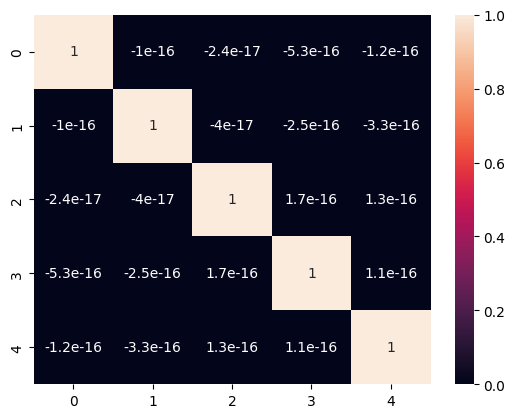

In [22]:
X_pca = pca.fit_transform(X_scaled)
corrmat = np.corrcoef(X_pca.transpose())
sns.heatmap(corrmat, annot=True)

In [23]:
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i, random_state = 1)
    kmeans.fit(X_pca)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    print(i, silhouette_avg)

2 0.28493960133786356
3 0.3079769786519014
4 0.32041373564415604
5 0.24796729244571458
6 0.23487112340554764
7 0.24412506184527263
8 0.2398550154102064
9 0.23319218781273082
10 0.22759425188427676


<Axes: xlabel='K-Means_Cluster_ID', ylabel='child_mort'>

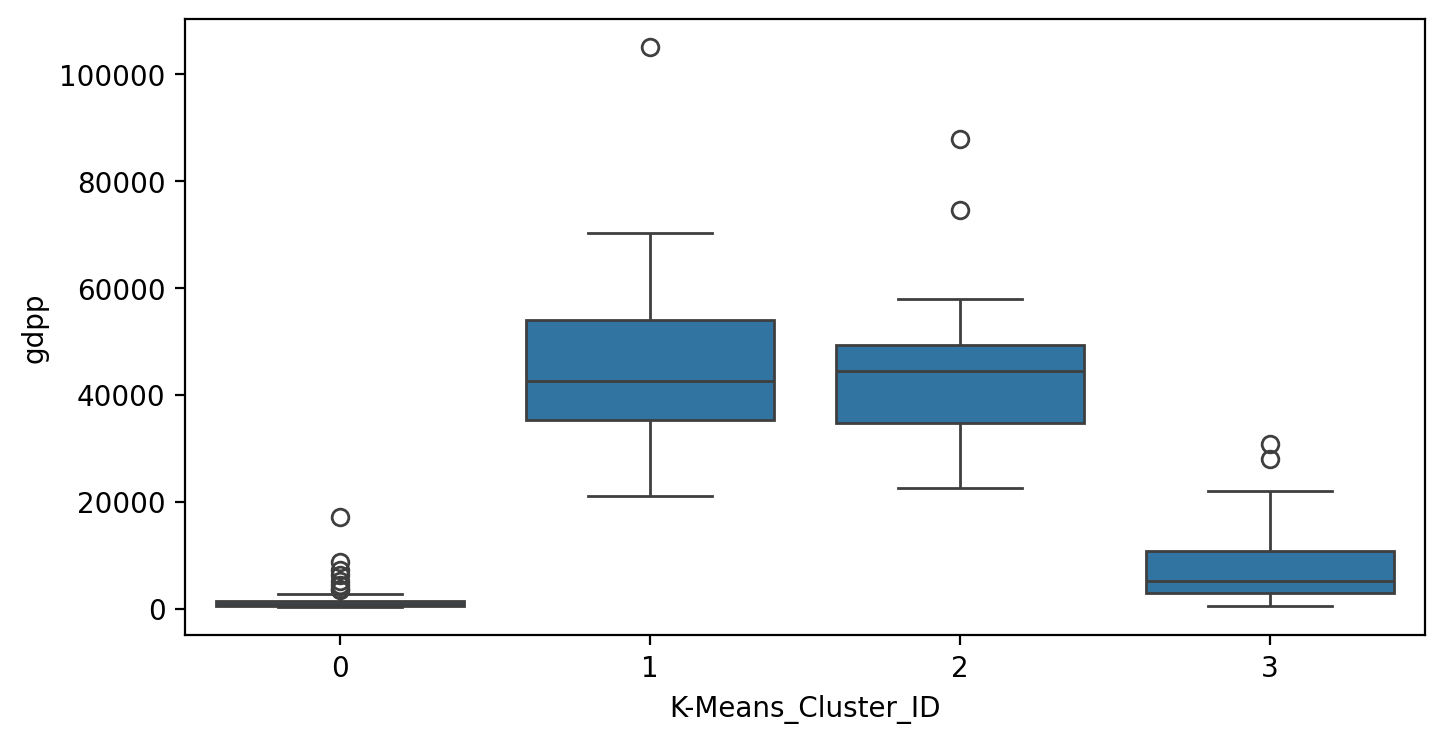

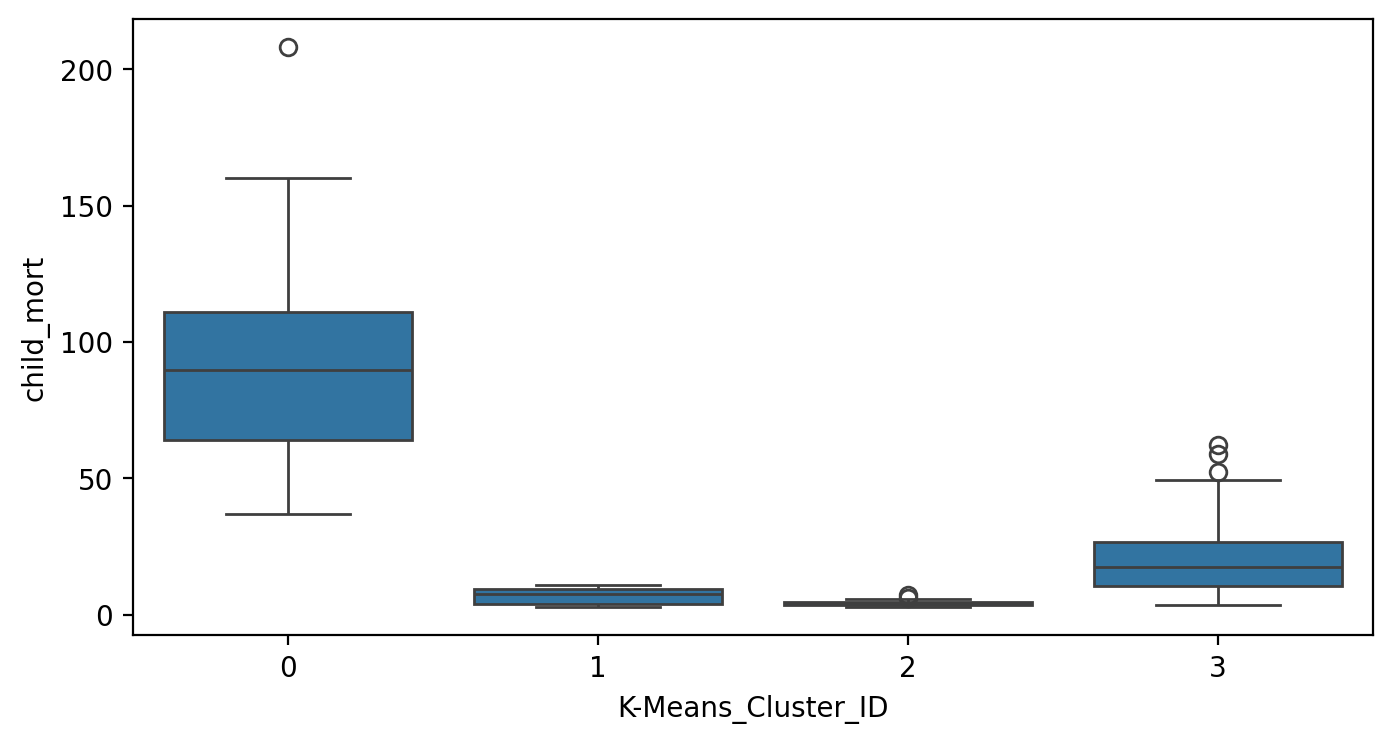

In [24]:
kmeans = KMeans(n_clusters=4, random_state=1)
kmeans.fit(X_pca)
country_data['K-Means_Cluster_ID'] = kmeans.labels_
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='K-Means_Cluster_ID', y='gdpp', data=country_data)
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='K-Means_Cluster_ID', y='child_mort', data=country_data)

In [28]:
K_Means_countries = country_data[country_data['K-Means_Cluster_ID'] == 1]
K_Means_countries.sort_values(by = 'life_expec')

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,K-Means_Cluster_ID
157,United Arab Emirates,8.6,77.7,3.66,63.6,57600,12.500,76.5,1.87,35000,1
23,Brunei,10.5,67.4,2.84,28.0,80600,16.700,77.1,1.84,35300,1
82,Kuwait,10.8,66.7,2.63,30.4,75200,11.200,78.2,2.21,38500,1
123,Qatar,9.0,62.3,1.81,23.8,125000,6.980,79.5,2.07,70300,1
98,Malta,6.8,153.0,8.65,154.0,28300,3.830,80.3,1.36,21100,1
73,Ireland,4.2,103.0,9.19,86.5,45700,-3.220,80.4,2.05,48700,1
91,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000,1
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600,1
